In [1]:
using Pkg
Pkg.activate("C:/Users/ibzja/Documents/UPF_2022_2026/4t/2n_trimestre/Practiques_tutelades/CellBasedModels.jl")
using CellBasedModels 
using GeometryBasics
using Distributions
using GLMakie, Colors
Makie.inline!(true)
using CSV, DataFrames, Statistics
using Printf, JLD2
using SpecialFunctions
using LsqFit
using LinearAlgebra
using DifferentialEquations, StaticArrays

  Activating project at `C:\Users\ibzja\Documents\UPF_2022_2026\4t\2n_trimestre\Practiques_tutelades\CellBasedModels.jl`


In [2]:
collective_neg_pos_model = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :S => Float64,
        # :S_2 => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64
    ),

    medium = Dict(
        :mm => Float64,
        :ve => Float64
    ),

    agentODE = quote
  
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)

        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)

        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)

        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)

        end

        mmb = max(0, mm[idx,idy])

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka))
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)      

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)
       

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))     

        dt(x) = vx 
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)     
        
    end,

    agentRule = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]

        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)        
       
     # Adding population every 100 steps
        # p_add = 0.001

        # if i1_ == 1
        #     if rand() < p_add
        #         for k in 1:10
        #             @addAgent(
        #                 x = xmin + 10,
        #                 y = ymax/2 + 10 + rand()*(ymax - (ymax/2) - 10),
        #                 theta = 2 * pi,
        #                 l = 3
        #             )
        #         end
        #     end
        # end

        v_run = v
        v_tumble = 0.25 
        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        mm[idx,idy] += S

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 
            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                  
            if P < P_rt             
                active = false
                vx = speed* cos(theta) + ve[idx, idy]*0.5
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn() 
                        
            else    
                active = true
                vx = speed * cos(theta) + ve[idx, idy]*0.5
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
                     
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta) + ve[idx, idy]*0.5
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()

            else
                active = false
                vx = speed* cos(theta) + ve[idx, idy]*0.5
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()

            end
        end
#Reflective, add/remove
        # if x <= xmin
        #     x = xmin + (xmin - x)
        #     theta = pi - theta
        # elseif x >= xmax
        #     @removeAgent()
        # end

        # if y >= ymax
        #     y = 2*ymax - y
        #     theta = 2*pi - theta
        # end
# Periodic boundry conditions
        if x < xmin
            x += (xmax - xmin)
        elseif x > xmax
            x -= (xmax - xmin)
        end

        if y >= ymax
            y = 2*ymax - y
            theta = 2*pi - theta
        end

        if y <= wall_y(x, 62, 100, 250, 20, 500)
            x_new = clamp(round(Int, x/2), 1, 250)
            y_new = clamp(round(Int, y/2), 1, 250)

            if MYT[x_new, y_new] == 1 && MXR[x_new, y_new] == 1
                y = wall_y(x, 62, 100, 250, 20, 500) + 1
                x = x + 1
                theta = theta + pi

            elseif MYT[x_new, y_new] == 1 && MXL[x_new, y_new] == 1
                y = wall_y(x, 62, 100, 250, 20, 500) + 1
                x = x - 1
                theta = theta + pi

            elseif MYT[x_new, y_new] == 1 
                y = wall_y(x, 62, 100, 250, 20, 500) + 1
                theta = 2*pi - theta

            elseif MXR[x_new, y_new] == 1
                x = x + 2
                theta = pi - theta

            elseif MXL[x_new, y_new] == 1
                x = x - 2
                theta = pi - theta

            elseif M0[x_new, y_new] == 1        # Esta dins, no pinta res allí
                x_old = x[t-1]
                y_old = y[t-1]
                nsteps = ceil(Int, max(abs(x - x_old), abs(y - y_old)))

                hit_type = nothing

                for s in 0:nsteps
                    xs = x_old + (x - x_old) * s / nsteps
                    ys = y_old + (y - y_old) * s / nsteps

                    xi = clamp(round(Int, xs/2), 1, 250)
                    yi = clamp(round(Int, ys/2), 1, 250)

                    if MXR[xi, yi]
                        hit_type = :right
                        break
                    elseif MXL[xi, yi]
                        hit_type = :left
                        break
                    elseif MYT[xi, yi]
                        hit_type = :horizontal
                        break
                    end
                end
                if hit_type == :right
                    x = x_old
                    theta = pi - theta

                elseif hit_type == :left
                    x = x_old
                    theta = pi - theta

                elseif hit_type == :horizontal
                    y = y_old
                    theta = 2*pi - theta
                end
                                
            end
        end
    end,


    mediumODE = quote

        if @mediumInside()
    # --- geometry mask FIRST (do NOT overwrite mm itself) ---
            if M0[i1_, i2_]
                dt(mm) = 0

            else
                dt(mm) = DMedium * (@∂2(1, mm) + @∂2(2, mm)) - delta * mm - ve[i1_, i2_] * @∂(1, mm)

            end
            mm = MXR[i1_, i2_] ? mm[i1_ + 1, i2_] : mm
            mm = MXL[i1_, i2_] ? mm[i1_ - 1, i2_] : mm
            mm = MYT[i1_, i2_] ? mm[i1_, i2_ + 1] : mm
            # Reflective
        # elseif @mediumBorder(1,-1) # left PBC
        #     mm = mm[1, i2_]

        # elseif @mediumBorder(1,1) #right PBC
        #     mm = mm[NMedium[1] - 1, i2_]

        # elseif @mediumBorder(2,-1) # down NBC (newmann)
        #     mm = 0

        # elseif @mediumBorder(2,+1)
        #     mm = mm[i1_, NMedium[2] - 1]
# Periodic boundry conditions
        elseif @mediumBorder(1,-1) # left PBC
            mm = mm[NMedium[1] - 1, i2_]

        elseif @mediumBorder(1,1) #right PBC
            mm = mm[1, i2_]

        elseif @mediumBorder(2,-1) # down NBC (newmann)
            mm = 0

        elseif @mediumBorder(2,+1)  # s'ha de quedar reflective que l'altra es 0
            mm = mm[i1_, NMedium[2] - 1]

        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler()
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)
	ve (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    if

In [3]:
function wall_y(x, w, d, y0, xstart, xend)
    
    # outside wall region → flat at baseline
    if x < xstart || x > xend
        return y0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    # square-wave pattern (0 or -d), then shift up by y0
    return y0 - d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

wall_y (generic function with 1 method)

In [5]:
dx = (com.simBox[1,2] - com.simBox[1,1]) / com.NMedium[1]
dy = (com.simBox[2,2] - com.simBox[2,1]) / com.NMedium[2]

xcoord(i1_) = com.simBox[1,1] + (i1_ - 1) * dx
ycoord(i2_) = com.simBox[2,1] + (i2_ - 1) * dy
Nx = com.NMedium[1]
Ny = com.NMedium[2]

mask_raw = zeros(Bool, com.NMedium[1], com.NMedium[2])
M0 = zeros(Bool, com.NMedium[1], com.NMedium[2])
MXL = zeros(Bool, com.NMedium[1], com.NMedium[2])
MXR = zeros(Bool, com.NMedium[1], com.NMedium[2])
MYT = zeros(Bool, com.NMedium[1], com.NMedium[2])

for i in 1:Nx, j in 1:Ny
    x = xcoord(i)
    y = ycoord(j)
    mask_raw[i,j] = y < wall_y(x, 62, 100, 250, 20, 500)
end

for i in 2:Nx-1, j in 2:Ny-1
    if mask_raw[i,j] &&
       mask_raw[i+1,j] &&
       mask_raw[i-1,j] &&
       mask_raw[i,j+1] &&
       mask_raw[i,j-1] &&
       mask_raw[i+1,j+1] &&
       mask_raw[i+1,j-1] &&
       mask_raw[i-1,j+1] &&
       mask_raw[i-1,j-1]

        M0[i,j] = true
    end
end

for i in 2:Nx-1, j in 2:Ny-1

    if M0[i,j] == 1

        # --- HORIZONTAL LINES ---
        # bottom edge (neighbor below is outside)
        if M0[i, j-1] == 0
            MYT[i,j] = true
        end

        # top edge (neighbor above is outside)
        if M0[i, j+1] == 0
            MYT[i,j] = true
        end


        # --- LEFT WALL ---
        if M0[i-1, j] == 0
            MXL[i,j] = true
        end


        # --- RIGHT WALL ---
        if M0[i+1, j] == 0
            MXR[i,j] = true
        end

    end
end

In [6]:
com = Community(
    collective_neg_pos_model,
    N=1000,
    dt=0.01,
    # simBox = [-100.0 100.0; -100.0 100.0],
    simBox = [0.0 500.0; 0.0 500.0],
    NMedium = [250,250]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

com.v = 20.0    #Velocitat bacteries biològica
# com.v = 10.0
# com.v = 0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 20
com.delta = 0.00125
# com.ve = 10

com.x = rand(Uniform(com.simBox[1,:]...),com.N)
# com.x = 15
com.y = rand(Uniform(250, 500),com.N)
# com.y = 450

com.theta = rand(Uniform(0, 2*pi),com.N)
# com.theta = rand(Uniform(pi/2,(3*pi)/2),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 
com.S = 0.0025

com.ve = zeros(com.NMedium[1], com.NMedium[2])

for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
    y = ycoord(i2)

    if y > 250
        com.ve[i1, i2] = 10
    else
        com.ve[i1, i2] = 0.0
    end
end

In [7]:
outfile = "cript_PBC_2.jld2"
steps = 20000

loadToPlatform!(com, preallocateAgents=1000)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    # meta = JLD2.Group(file, "meta")
    # meta["N"] = com.N
    # meta["NMedium"] = com.NMedium
    # meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        CellBasedModels.step!(com)
        if step % 100 == 0
            stepname = @sprintf("step_%06d", step)
            g = JLD2.Group(file, stepname)

            # Agent-level arrays (length = N)
            g["x"] = copy(com.x)
            g["y"] = copy(com.y)
            g["theta"] = copy(com.theta)

            # Medium grid (saved once per step)
            g["mm_grid"] = copy(com.mm)
        end
    end
end


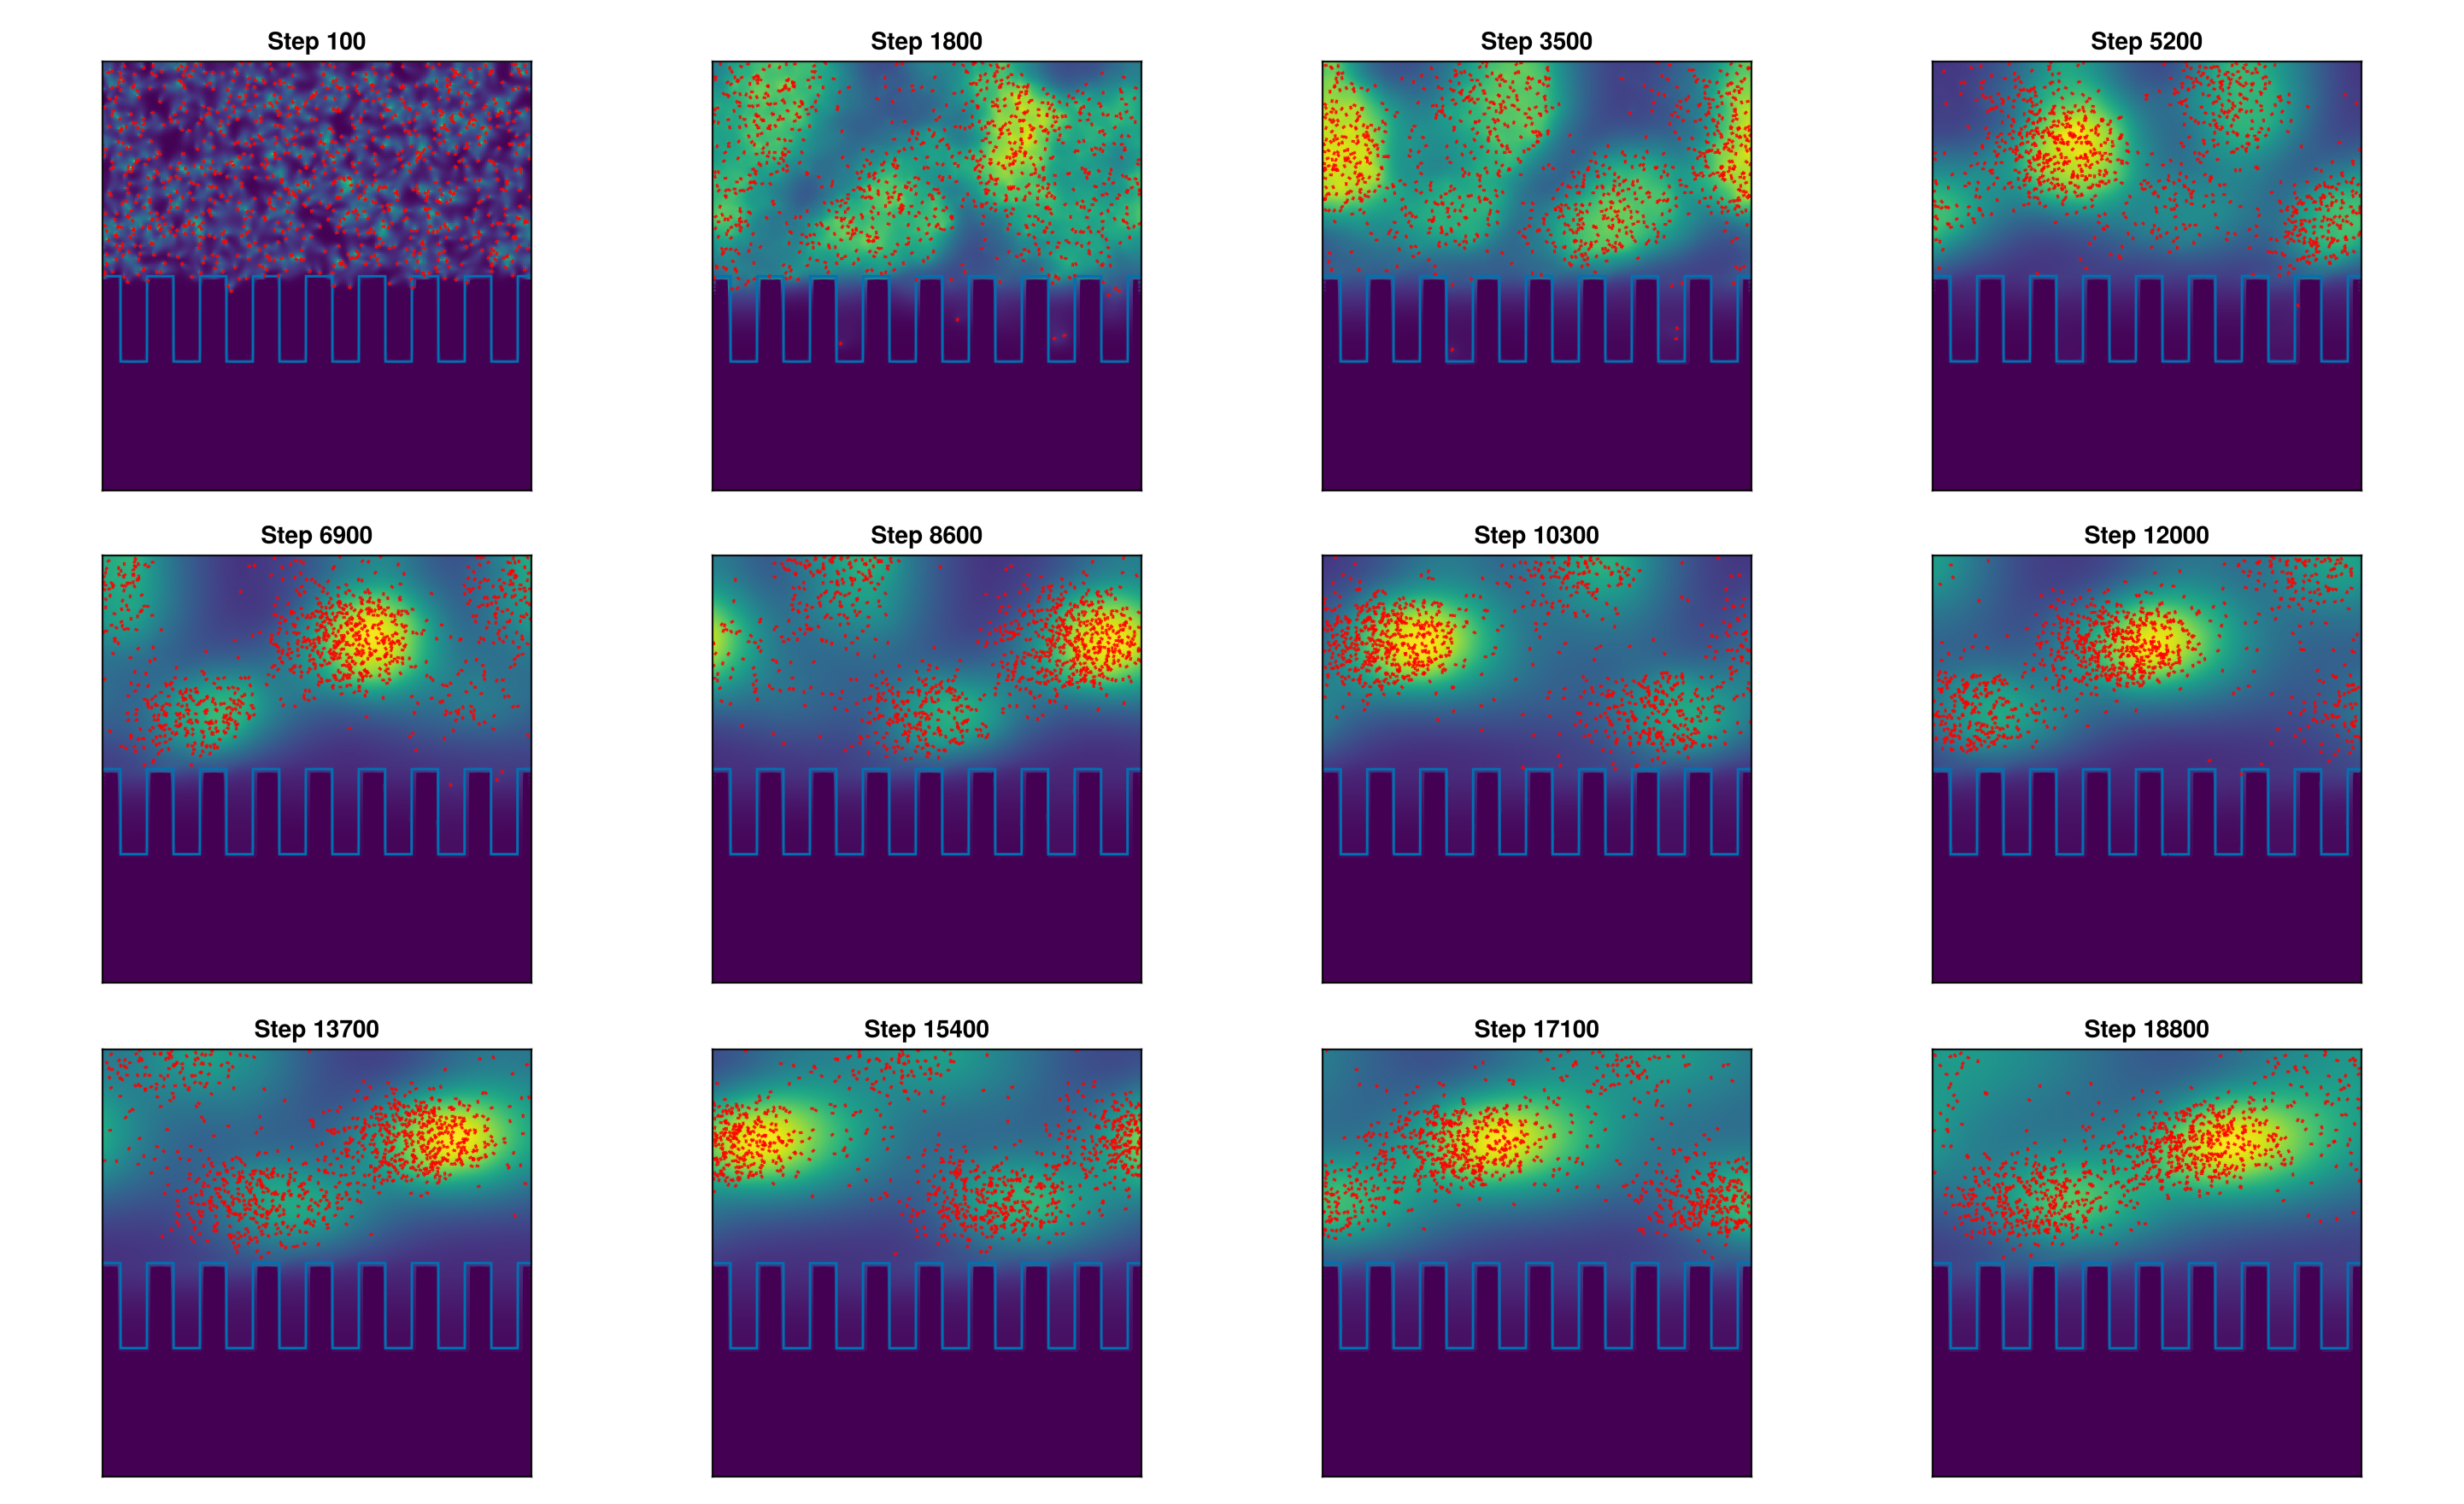

GLMakie.Screen(...)

In [8]:
fig4 = Figure(size=(900*4,600*4))
# steps = 5000
model_steps = 100:100:20000
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/12):end]

jldopen("cript_PBC_2.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1
        # col1 = columns[j]
        ax = Axis(fig4[row, col], aspect = 1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (com.NMedium[1], com.NMedium[2]))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:500
        ys = [wall_y(x, 62, 100, 250, 20, 500) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            if x[i] != 0
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end
        end
        hidedecorations!(ax)

        # Colorbar(fig4[1, j*2], hm, label="Chemoattractant")

    end
end
Makie.inline!(true)
display(fig4)

In [9]:
save("Plots/Cripts/Test_sims/c_PBC_n_05_lc_100_ve_10.png", fig4)

In [90]:
data = Dict{Int, Any}()
steps = 15000
jldopen("cript_test.jld2", "r") do file
    for step in 1:steps
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "x" => copy(key["x"]),
            "y" => copy(key["y"]),
            "theta" => copy(key["theta"]),
            # "l" => copy(key["l"]),
            "mm_grid" => copy(key["mm_grid"])
        )
    end
end

# Setup plot
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1], aspect=1, title="Step 1", xlabel="x (μm)", ylabel="y (μm)")

# Initialize scatter and lines
scatter_plt = scatter!(ax, Float64[], Float64[], color=:red, markersize=5, label="Bacteria")
# source_plt = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")

# Slider
slider = Slider(fig[2, 1:2], range=1:steps, startvalue=1, update_while_dragging = true)
Label(fig[2, 3], "Step: ", fontsize=14)

# Update function
function update_plot(step)
    empty!(ax)

    g = data[step]
    mm_grid = g["mm_grid"]
    mm = reshape(mm_grid, (100,100))

    hm = heatmap!(ax, 
                range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                mm_grid, 
                colormap=:viridis
                    )

    # Colorbar(fig[1, 2], hm, label="mm (μM)")

    
    x = g["x"]
    y = g["y"]
    theta = g["theta"]
    l = 3

    # Update scatter
    scatter_plt[1] = x
    scatter_plt[2] = y

    # Compute rod endpoints
    xs1 = x .+ l ./ 2 .* cos.(theta)
    ys1 = y .+ l ./ 2 .* sin.(theta)
    xs2 = x .- l ./ 2 .* cos.(theta)
    ys2 = y .- l ./ 2 .* sin.(theta)
    
    for i in 1:length(x)
        if x[i] != 0
            linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end
    end

    # Update title
    ax.title = "Step $step"

    # Redraw
    autolimits!(ax)
end

# Connect slider to update
on(slider.value) do val
    update_plot(Int(val))
end

# Initialize
update_plot(1)

# Display
# display(fig)

GLMakie.activate!()
display(fig)

GLMakie.Screen(...)

# Analisi

In [ ]:
data = Dict{Int, Any}()
steps = 50000
jldopen("cript_test.jld2", "r") do file
    for step in 1:steps
        key = file[@sprintf("step_%06d", step)]
        data[step] = Dict(
            "x" => copy(key["x"]),
            "y" => copy(key["y"]),
            "mm_grid" => copy(keu["mm_grid"])
        )
    end
end



In [131]:
right_wall = findall(MXR[:, 50] .== 1) .* 2
left_wall = findall(MXL[:, 50] .== 1) .* 2
x1_1, x1_2, x1_3, x1_4 = right_wall[1:4]
x2_1, x2_2, x2_3, x2_4 = left_wall[2:5]

4-element Vector{Int64}:
  40
  90
 140
 190

In [194]:
counts = zeros(4, steps)

for i in 1:steps
    g = data[i]
    x = g["x"]
    y = g["y"]

    count1 = 0
    count2 = 0
    count3 = 0
    count4 = 0

    for j in 1:length(x)
    
        if x2_1 > x[j] > x1_1 && y[j] < 110
            count1 += 1
        elseif x2_2 > x[j] > x1_2 && y[j] < 110
            count2 += 1
        elseif x2_3 > x[j] > x1_3 && y[j] < 110
            count3 += 1
        elseif x2_4 > x[j] > x1_4 && y[j] < 110
            count4 += 1
        end
    end

    counts[1, i] = count1
    counts[2, i] = count2
    counts[3, i] = count3
    counts[4, i] = count4
end

In [197]:
fig = Figure(size=(900, 600))
ax = Axis(fig[1, 1], xlabel = "Time", ylabel = "Nº cells", title = "Cript colonization over time")
lines!(ax, (1:steps)*0.01, counts[1, :], label = "Cript 1")
lines!(ax, (1:steps)*0.01, counts[2, :], label = "Cript 2")
lines!(ax, (1:steps)*0.01, counts[3, :], label = "Cript 3")
lines!(ax, (1:steps)*0.01, counts[4, :], label = "Cript 4")
fig[1,2] = Legend(fig, ax, "Cripts")
fig


In [198]:
save("Plots/Cripts/colonization_over_time_500s.png", fig)

# Average mm in each cript

In [ ]:
ncripts = 4
grid_values = zeros(ncripts, steps)

x2 = left_wall[2:5] ./ 2
x1 = right_wall[1:4] ./2
y1 = 100 - (10 / 2)
y2 = 100 - (110 / 2)

for i in 1:steps
    g = data[i]
    grid = g["mm_grid"]
    for j in 1:ncripts
        cript = grid[x1[j]:x2[j], y2:y1]
        mm_mean = mean(cript)

        grid_values[j, i] = mm_mean

    end






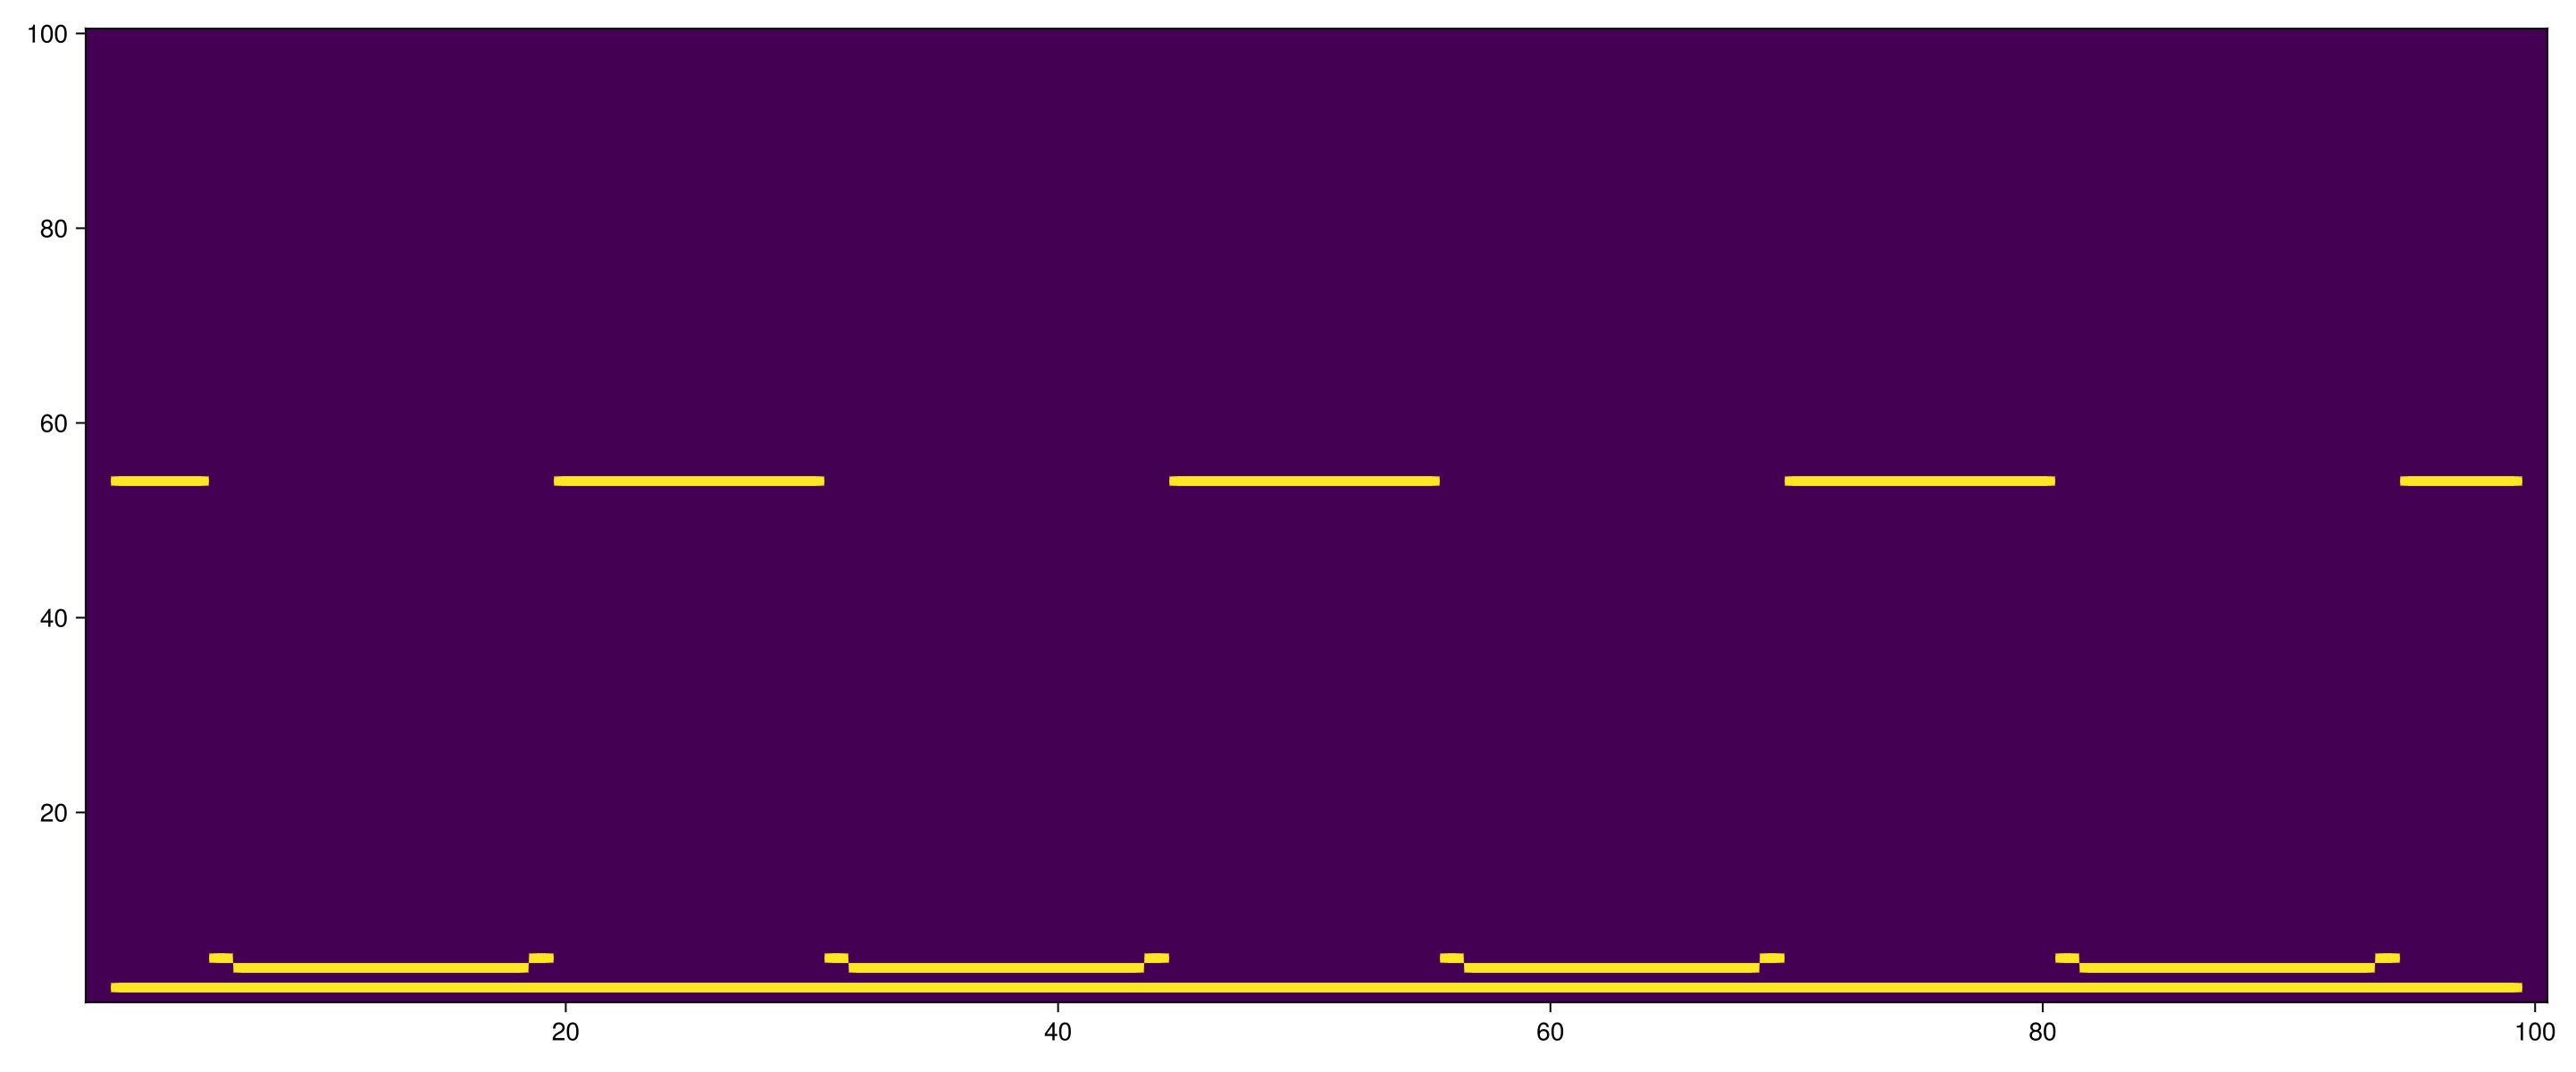

In [9]:
fig3 = Figure(size=(2100,600))
ax3 = Axis(fig3[1,1])
# ax3_2 = Axis(fig3[1,2])
# ax3_3 = Axis(fig3[1,3])
hm = heatmap!(ax3, MYT)
# hm_1 = heatmap!(ax3_2, mask)
# hm_2 = heatmap!(ax3_3, MXL)
# contour!(ax3_2, M0, linewidth = 0.5)
# contour!(ax3_3, M0, linewidth = 0.5)
# contour!(ax3, MXR, linewidth = 0.5)
# contour!(ax3, MXL, linewidth = 0.5)
# contour!(ax3, MYT, linewidth = 0.5)
# xs = 0:1:200
# ys = 0:1:200
# ys = [wall_bottom(x,10, 200, 110, 100) for x in xs]
# lines!(ax3, xs, ys)
# hm = heatmap!(ax3, Z)
Makie.inline!(true)

fig3

In [19]:
function is_wall(x, y; w=10, d=20)
    # Base wall at y = 0
    if y == 0
        return iseven(fld(x, w))  # alternating solid / gap
    end

    # Indentations going downward
    if y < 0
        return isodd(fld(x, w)) && y >= -d
    end

    return false
end

is_wall (generic function with 1 method)

In [ ]:
function wall_y_test(x; w=10.0, d=20.0)
    return -d * floor((1 + sign(sin(2π * x / w))) / 2)
end


wall_y (generic function with 1 method)

In [55]:
function wall_y(x; xstart=20.0, xend=180.0, w=10.0, d=20.0)
    
    # outside wall region → no wall (or treat as flat boundary)
    if x < xstart || x > xend
        return 0.0
    end

    # shift x so pattern starts at xstart
    ξ = x - xstart

    return -d * floor((1 + sign(sin(2π * ξ / w))) / 2)
end

wall_y (generic function with 1 method)

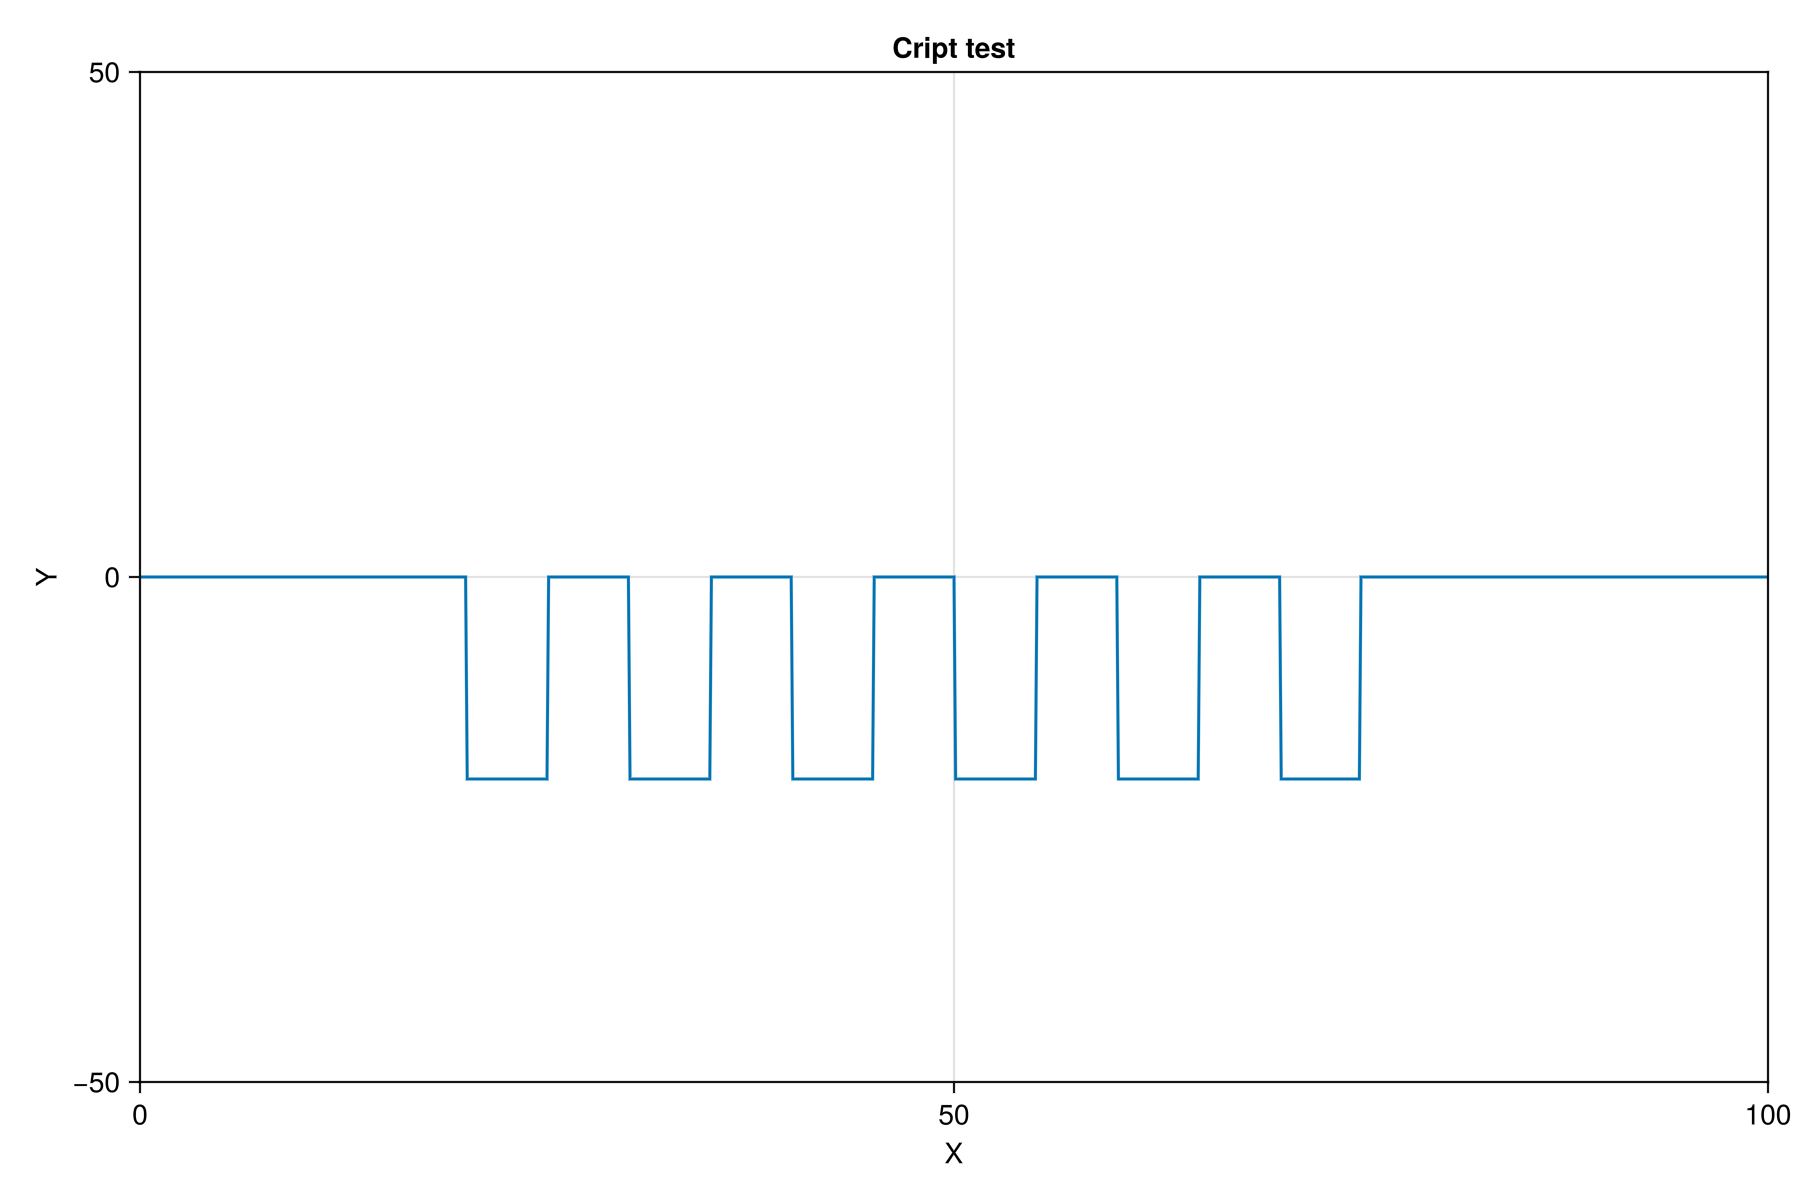

In [27]:
fig = Figure(size=(900,600))
ax = Axis(fig[1,1], title = "Cript test", xlabel = "X", ylabel = "Y")

xs = 0:0.1:100
ys = [wall_y(x) for x in xs]

lines!(ax, xs, ys)
xlims!(ax, 0, 100)
ylims!(ax, -50, 50)
fig

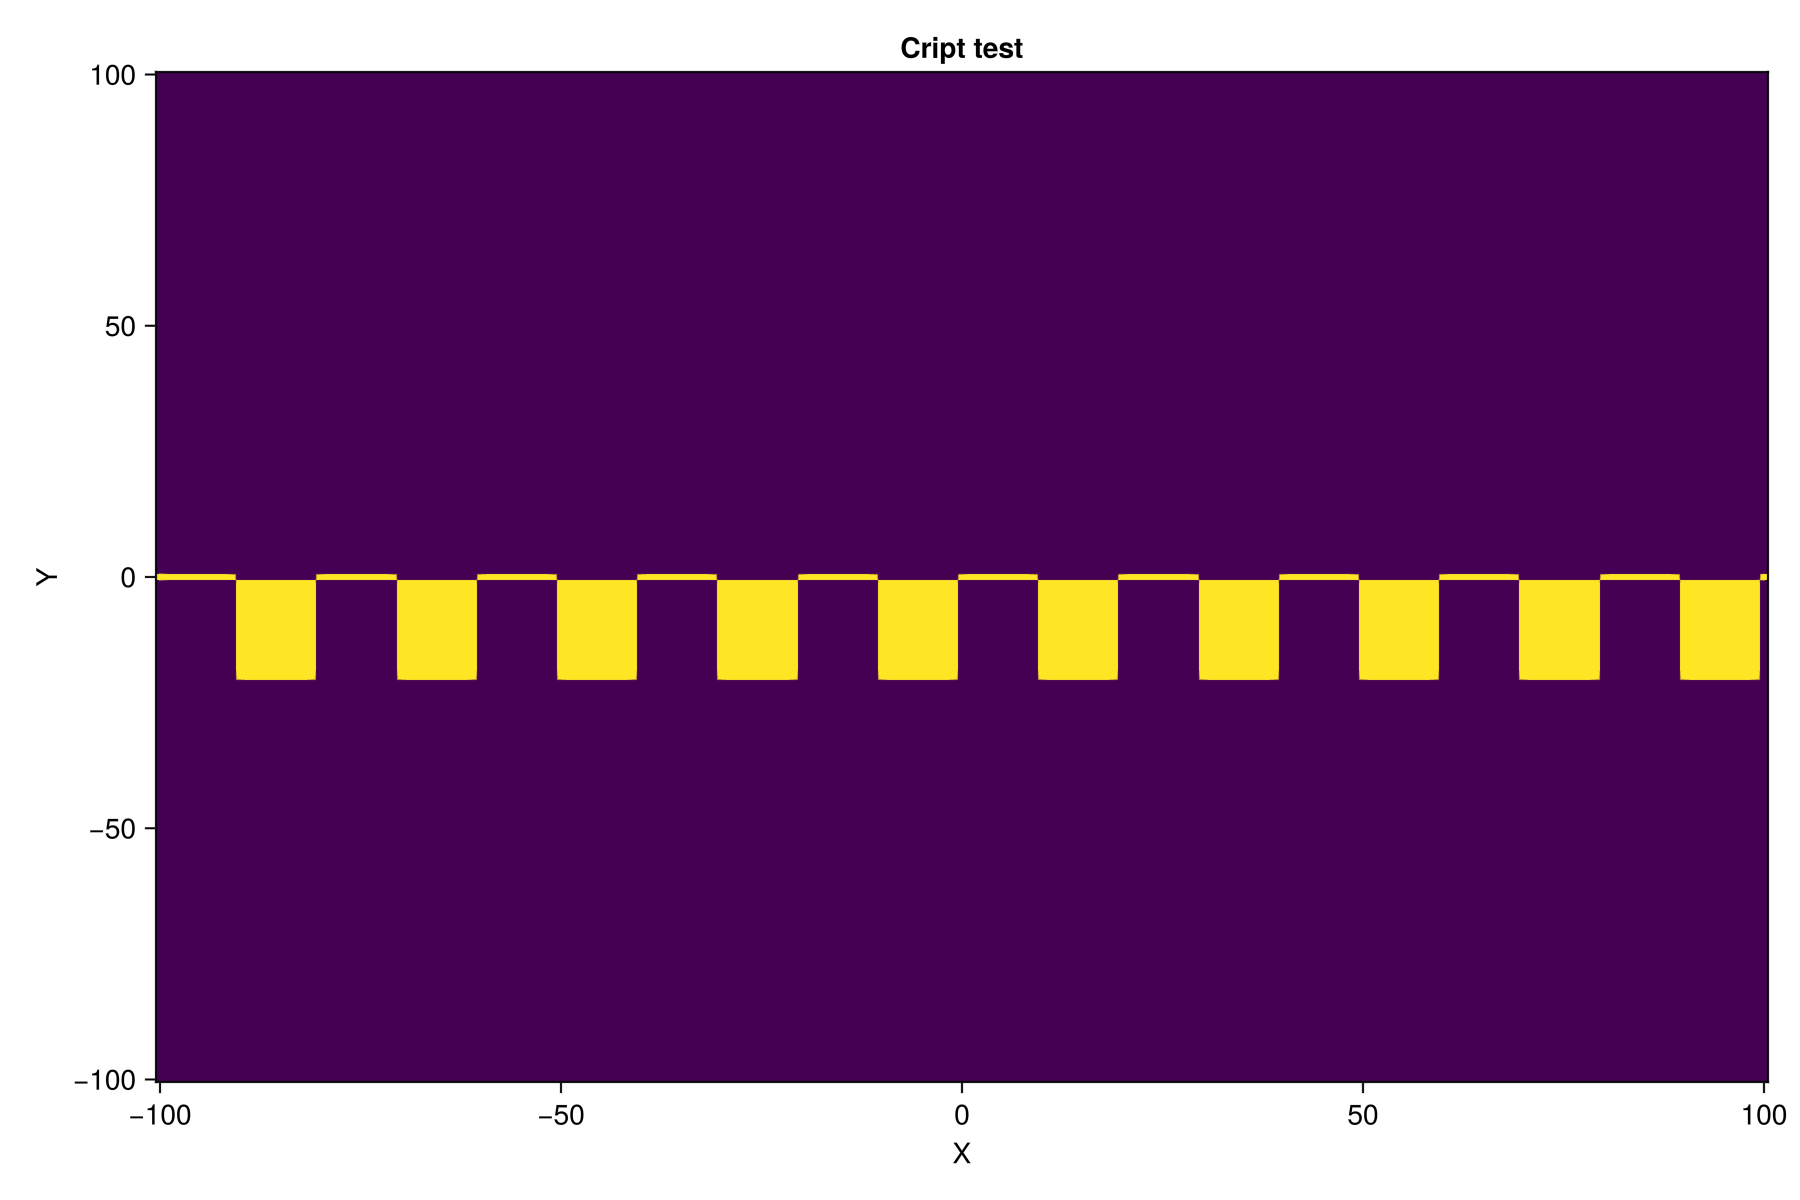

In [20]:
fig2 = Figure(size=(900,600))
ax2 = Axis(fig2[1,1], title = "Cript test", xlabel = "X", ylabel = "Y")

xs = -100:1:100
ys = -100:1:100
Z = [is_wall(x, y) ? 1.0 : 0.0 for x in xs, y in ys]
heatmap!(ax2, xs, ys, Z)
fig2

# test

In [ ]:
padding = ABM(2,
    agent = Dict(
        :vx => Float64,
        :vy => Float64,
        :v => Float64,  #Swimming speed
        :theta => Float64,
        :d => Float64,
        :l => Float64,
        :m => Float64,
        :fx => Float64,
        :fy => Float64,
        :W => Float64,
        :pressure => Float64,
        :active => Bool,

        :S => Float64,
        # :S_2 => Float64,

        :methyl => Float64, #Receptor methylation
        :Yp => Float64, #CheYP levels, probability of tumblingç
        :G => Float64,
        :λ => Float64,
        :P => Float64,
        :M => Float64,
        :F => Float64,
        :A => Float64,
        :M => Float64,
        :Ds => Float64

        # :xs => Float64,
        # :ys => Float64
        
    ),

    model = Dict(

        :Dr_run => Float64,

        :ε0 => Float64, #Energy parameters
        :ε1 => Float64,
        :ε2 => Float64,
        :ε3 => Float64,
        :K => Float64,
        :Nrec => Float64, #Cooperativity
        :Ki => Float64, #Dissociation constants
        :Ka => Float64,
        :τm => Float64, #Methylation adaptation timescale
        :α => Float64,      #Total Yp pool
        :ωFrec => Float64,     #Basal switching frequency
        :Ky => Float64,         #CheA - CheY phosphorylation rate
        :Z => Float64,          #CheZ concentration
        :Kz => Float64,         #CheZ mediated dephosphorylation rate
        :Yy => Float64,         #Basa Yp leak

        :DMedium => Float64,
        :delta => Float64
    ),

    medium = Dict(
        :mm => Float64,
        :ve => Float64
    ),

    agentODE = quote
  
        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]


        idx = Int(floor(Int, x/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        idy = Int(floor(Int, y/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        
        # X direction
        if x < xmin
            idx = Int(floor(Int, (x+(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x += (xmax - xmin)
        elseif x > xmax
            idx = Int(floor(Int, (x-(xmax - xmin))/(simBox[1,2]-simBox[1,1])*NMedium[1])+NMedium[1]/2)
        #     x -= (xmax - xmin)
        end

        # # Y direction
        if y < ymin
            idy = Int(floor(Int,(y+ymax-ymin)/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y += (ymax - ymin)
        elseif y > ymax
            idy = Int(floor(Int,(y-(ymax-ymin))/(simBox[2,2]-simBox[2,1])*NMedium[2])+NMedium[2]/2)
        #     y -= (ymax - ymin)
        end

        mmb = mm[idx,idy]

        F = ε0 + ε1 * methyl + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka))
        F0 = log(((Ky * (α - K)) / (K * (Kz * Z + Yy))) - 1)      

        mx = (ε0 + Nrec * log((1 + mmb / Ki) / (1 + mmb / Ka)) - F0) / (- ε1)
       

        A = 1 / (1 + exp(F))    

        Yp = (Ky * A * α) / ((Ky * A) + (Kz * Z) + Yy)

        G = ε2 / 4 - (ε3 / 2) / (1 + (K / Yp))      #CheYp segons activitat receptor

        dt(x) = vx  #Change position acording to constant speed afected by forces
        dt(y) = vy  
        dt(methyl) = -(1 / τm) * (methyl - mx)        #Methylation
        
    end,

    agentRule = quote

        xmin, xmax = simBox[1,1], simBox[1,2]
        ymin, ymax = simBox[2,1], simBox[2,2]
        
        # Adding population every 100 steps
        if i1_ == 1
            step = round(Int, t/dt)
            if step % 1000 == 0
                
                for k in 1:4
                    @addAgent(
                        x = xmin + 0.01*(xmax - xmin),   # small offset inside domain
                        y = ymax/2 + 12 + rand()*(ymax - (ymax/2)),
                        l = 3
                    )
                end
            end
        end

        v_run = v
        v_tumble = 0.25 

        speed = active ? v_run : v_tumble

        Dr_tumble = 6.2      
        Dr_total = active ? Dr_run : Dr_tumble

        mm[idx,idy] += S

        if active 
            λ = ωFrec*exp(-G)
            P = 1 - exp(-λ * dt)
                
        else
            λ = ωFrec*exp(G)
            P = 1 - exp(-λ * dt)  
                
        end


        if active 
            λrt = ωFrec*exp(-G) 

            P_rt = 1 - exp(-λrt * dt)
            P = rand() 
                                                    #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
            if P < P_rt             #Si rate alta = mes probabilitat de canvi. Per tant, si random number mes petit =  canvi. 
                active = false
                vx = speed* cos(theta)
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()           #Tumble = random reorientation
            else     #Si rate baixa 
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()       #Keep running, reorientation according to rotational difusion
            end

        else
            λtr = ωFrec*exp(G) 
            P_tr = 1 - exp(-λtr * dt)
            P = rand()

            if P < P_tr
                active = true
                vx = speed * cos(theta)
                vy = speed * sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            else
                active = false
                vx = speed* cos(theta)
                vy = speed* sin(theta)
                theta += sqrt(2 * Dr_total * dt) * randn()
            end
        end

        ϵ = 1e-6

        if x <= xmin
            x = xmin + ϵ
            vx = abs(vx)
        elseif x >= xmax
            @removeAgent()
        end

        if y >= ymax
            y = ymax - ϵ
            vy = -abs(vy)
        end

            # # Bottom wall (geometry)
        if y <= wall_y(x, 50, 100, 110)
            y = wall_y(x, 50, 100, 110)
            vy = -vy
        end

    end,


    mediumODE = quote

        if @mediumInside()

    # --- geometry mask FIRST (do NOT overwrite mm itself) ---
            if M0[i1_, i2_]

                dt(mm) = 0

            else
                
                dt(mm) = DMedium * (@∂2(1, mm) + @∂2(2, mm)) - delta * mm + ve[i1_, i2_] * @∂(1, mm)

            end
            
            mm = MXR[i1_, i2_] ? mm[i1_ - 1, i2_] : mm
            mm = MXL[i1_, i2_] ? mm[i1_ + 1, i2_] : mm
            mm = MYT[i1_, i2_] ? mm[i1_, i2_ - 1] : mm

            
        elseif @mediumBorder(1,-1) # left PBC
            mm = mm[1, i2_]

        elseif @mediumBorder(1,1) #right PBC
            mm = mm[NMedium[1] - 1, i2_]

        elseif @mediumBorder(2,-1) # down NBC (newmann)
            mm = 0

        elseif @mediumBorder(2,+1)
            mm = mm[i1_, NMedium[2] - 1]

        end
    end,


    agentAlg = CBMIntegrators.Heun(),
    mediumAlg=DifferentialEquations.Euler()
)

PARAMETERS
	x (Float64 agent)
	y (Float64 agent)
	xₘ (Float64 medium)
	yₘ (Float64 medium)
	Ds (Float64 agent)
	F (Float64 agent)
	active (Bool agent)
	methyl (Float64 agent)
	l (Float64 agent)
	S (Float64 agent)
	M (Float64 agent)
	d (Float64 agent)
	λ (Float64 agent)
	v (Float64 agent)
	A (Float64 agent)
	fx (Float64 agent)
	vx (Float64 agent)
	fy (Float64 agent)
	m (Float64 agent)
	Yp (Float64 agent)
	P (Float64 agent)
	pressure (Float64 agent)
	vy (Float64 agent)
	W (Float64 agent)
	G (Float64 agent)
	theta (Float64 agent)
	ε1 (Float64 model)
	α (Float64 model)
	Z (Float64 model)
	Dr_run (Float64 model)
	Ka (Float64 model)
	ε3 (Float64 model)
	ε0 (Float64 model)
	DMedium (Float64 model)
	delta (Float64 model)
	Ky (Float64 model)
	Kz (Float64 model)
	K (Float64 model)
	ε2 (Float64 model)
	Nrec (Float64 model)
	τm (Float64 model)
	Yy (Float64 model)
	Ki (Float64 model)
	ωFrec (Float64 model)
	mm (Float64 medium)
	ve (Float64 medium)


UPDATE RULES
mediumODE
 if @mediumInside()
    if

In [548]:
com = Community(
    padding,
    N=1,
    dt=0.01,
    simBox = [0.0 200.0; 0.0 200.0],
    NMedium = [100,100]
)

m = 1/100
g = 1/10000
d = 1

com.Dr_run = 0.062

com.v = 20.0    #Velocitat bacteries biològica
# com.v = 10.0
# com.v = 0
# com.v = 5.0
# com.v = 2.5
# com.v = 1
# com.v = 0.1

com.ωFrec = 1.3
com.Ki = 0.0182
com.Ka = 3.0
com.Nrec = 6.0
com.ε0   = 6.0
com.ε1   = -1.0
com.ε2   = 80
com.ε3   = 80

com.τm = 1
# com.τm = 5.0
# com.τm = 10.0
# com.τm = 30.0

com.α   = 6.0

com.K = 2.0 

com.Ky = 100.0
com.Kz = 10.0
com.Z = 5.0
com.Yy = 0.1

com.m = 1.        
com.d = 1.        
com.l = 3;

com.DMedium = 20
com.delta = 0.00125
# com.ve = 10

# com.x = rand(Uniform(com.simBox[1,:]...),com.N)
com.x = 100
# com.y = rand(Uniform(com.simBox[2,:]...),com.N)
com.y = 180

com.theta = rand(Uniform(0,2π),com.N)

com.methyl .= 0.0
com.Yp .= com.K

com.active .= true 
com.S = 1

com.ve = zeros(com.NMedium[1], com.NMedium[2])

for i1 in 1:com.NMedium[1], i2 in 1:com.NMedium[2]
    y = ycoord(i2)

    if y > 100
        com.ve[i1, i2] = -0.4
    else
        com.ve[i1, i2] = 0.0
    end
end

In [549]:
outfile = "cript_test_2.jld2"
steps = 10000

loadToPlatform!(com, preallocateAgents=1000)
com.mm = zeros(Float64, com.NMedium...)

jldopen(outfile, "w") do file

    # -------------------------
    # Metadata (written once)
    # -------------------------
    # meta = JLD2.Group(file, "meta")
    # meta["N"] = com.N
    # meta["NMedium"] = com.NMedium
    # meta["steps"] = steps

    # -------------------------
    # Main loop
    # -------------------------
    for step in 1:steps
        CellBasedModels.step!(com)

        stepname = @sprintf("step_%06d", step)
        g = JLD2.Group(file, stepname)

        # Agent-level arrays (length = N)
        g["x"] = copy(com.x)
        g["y"] = copy(com.y)
        g["theta"] = copy(com.theta)

        # Medium grid (saved once per step)
        g["mm_grid"] = copy(com.mm)
    end
end


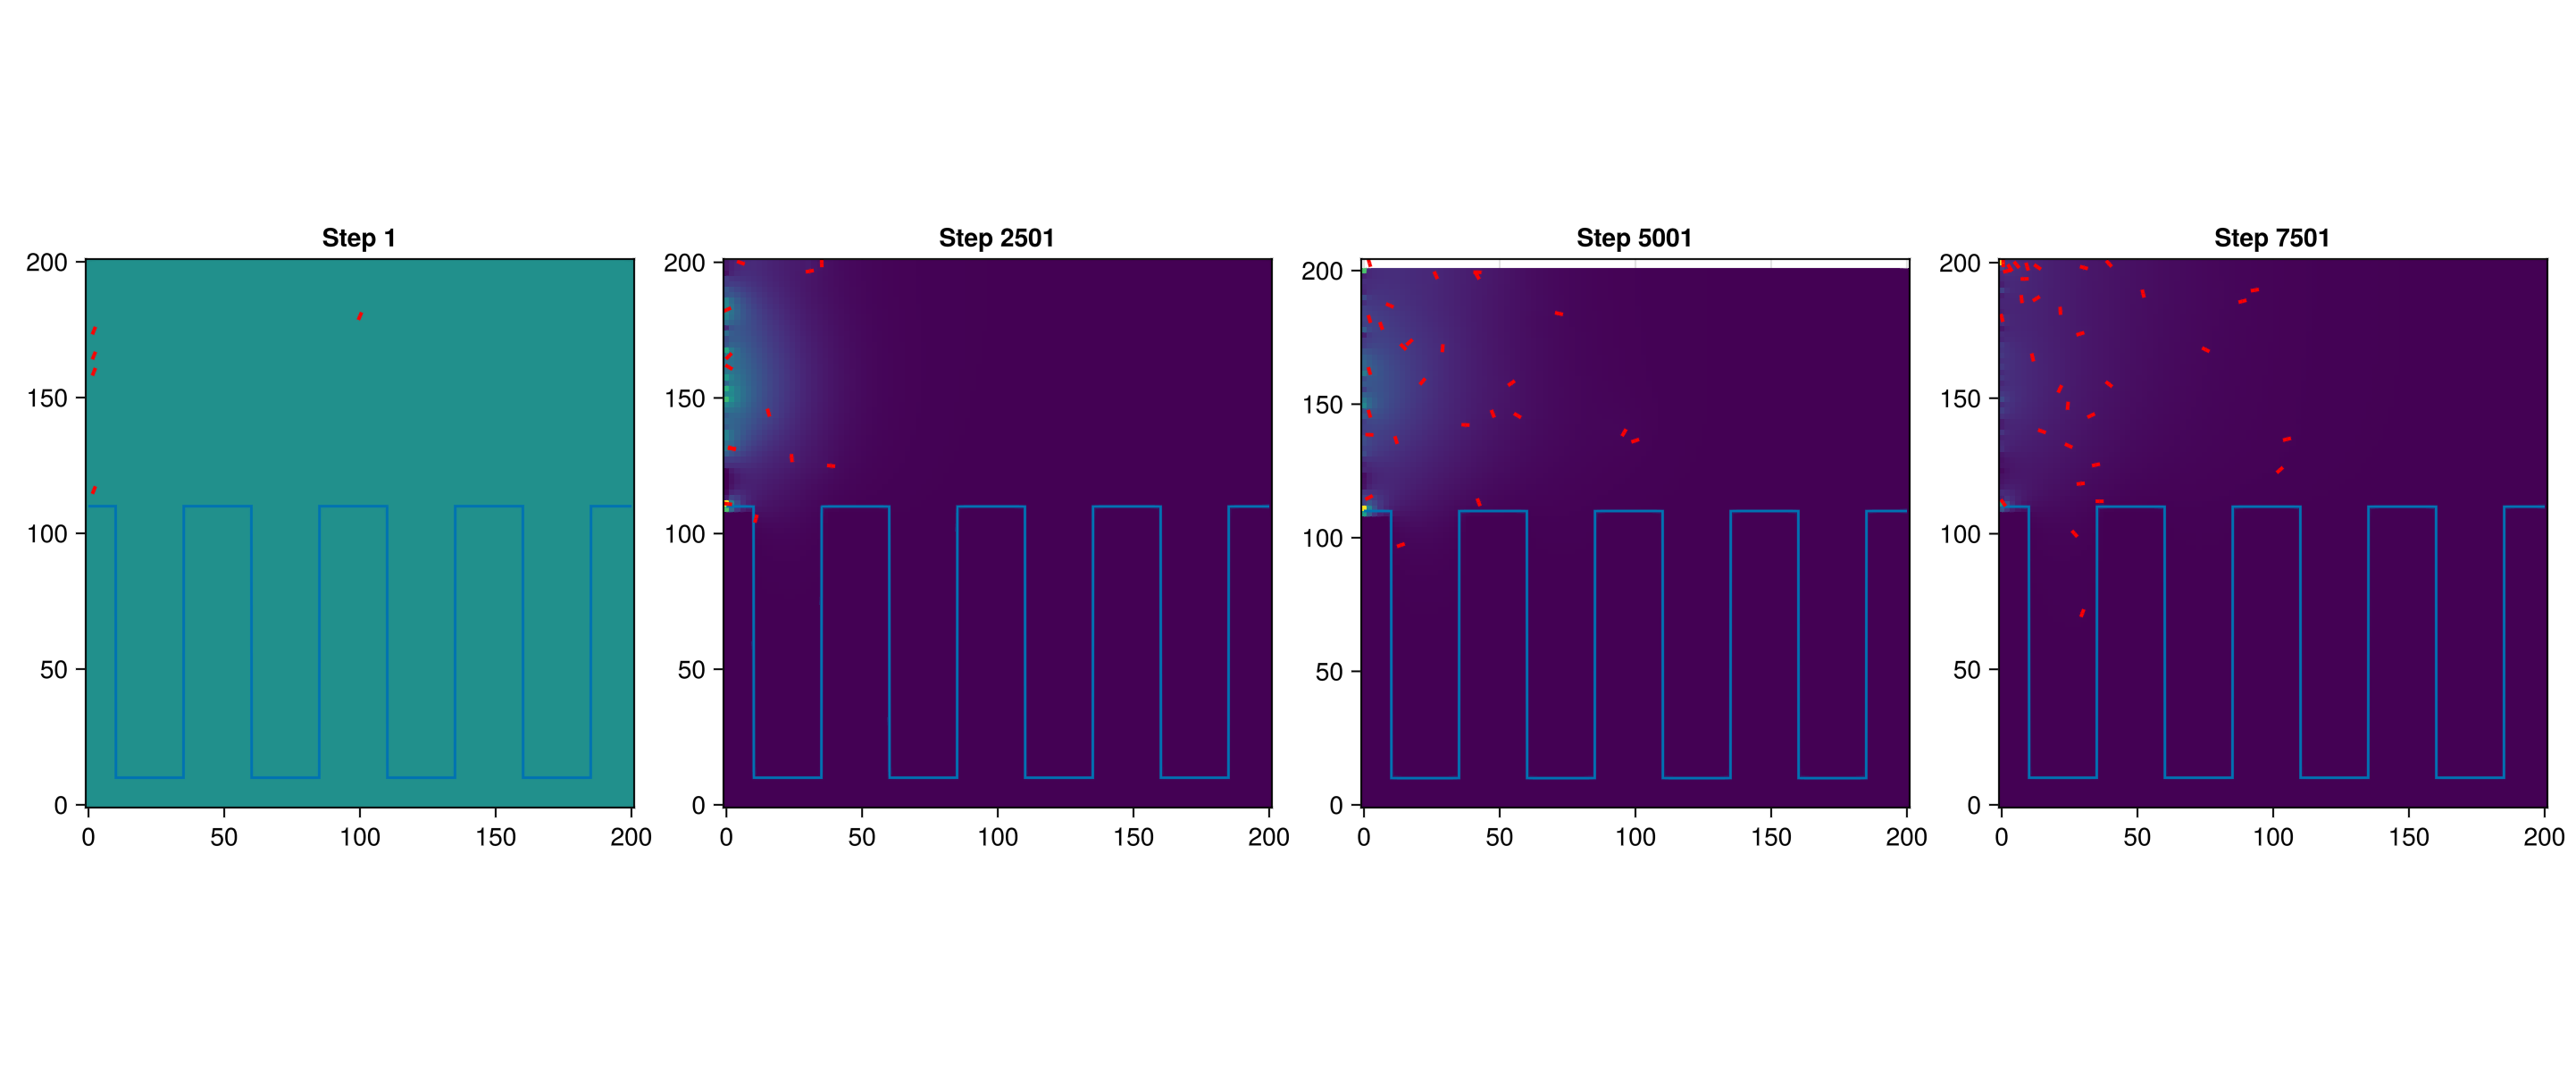

GLMakie.Screen(...)

In [550]:
fig4 = Figure(size=(900*4,600))
steps = 10000
model_steps = 1:steps
steps_to_plot = unique(model_steps)[1:round(Int, length(unique(model_steps))/4):end]
# steps_to_plot = [1, 100, 200, 300]

jldopen("cript_test_2.jld2", "r") do file 
    for (j, step) in enumerate(steps_to_plot)

        row = ceil(Int, j / 4)
        col = (j - 1) % 4 + 1

        ax = Axis(fig4[row, col], aspect=1, title="Step $step")

        g = file[@sprintf("step_%06d", step)]
    
        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (100,100))

        hm = heatmap!(ax, 
                    range(com.simBox[1,1],com.simBox[1,2],length=size(com.mm)[1]),
                    range(com.simBox[2,1],com.simBox[2,2],length=size(com.mm)[1]),
                    mm_grid, 
                    colormap=:viridis
                    )

        xs = 0:0.1:200
        ys = [wall_y(x) for x in xs]

        lines!(ax, xs, ys)


        x = g["x"]
        y = g["y"]
        theta = g["theta"]
        l = 3
            
        # Compute rod endpoints
        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            if x[i] != 0
                linesegments!([Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
                linesegments!([Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
            end
        end

        # Colorbar(fig4[1, 2*j], hm, label="Chemoattractant")

    end
end

display(fig4)

In [676]:
xgrid = range(0, 200, length=200)

ybottom = [wall_y(x, 50, 100, 110) for x in xgrid]
ybottom[10:50]

41-element Vector{Real}:
 110
  10.0
  10.0
  10.0
  10.0
  10.0
  10.0
  10.0
  10.0
  10.0
   ⋮
 110.0
 110.0
 110.0
 110.0
 110.0
 110.0
 110.0
 110.0
 110.0

In [ ]:
dy = diff(ybottom)

threshold = 1e-6

left_walls  = falses(length(xgrid))
right_walls = falses(length(xgrid))

for i in 2:length(dy)
    if dy[i] > threshold
        left_walls[i] = true
    elseif dy[i] < -threshold
        right_walls[i] = true
    end

end


4-element BitVector:
 1
 1
 1
 1

In [ ]:
filename = "cript_test.jld2"
steps = 10000
# Get all step keys
# steps = [k for k in keys(jldopen(filename, "r")) if startswith(k, "step_")]
# nsteps = length(steps)
steped = 1:20000
nsteps = length(steped)

# Define grid for heatmap (assuming 200x200)
# x_range = range(com.simBox[1,1], com.simBox[1,2], length=200)
# y_range = range(com.simBox[2,1], com.simBox[2,2], length=200)
x_range = range(-100, 100, length=200)
y_range = range(-100, 100, length=200)

# Initialize figure
fig = Figure(size = (900, 600))
ax = Axis(fig[1, 1], aspect=1, title = "Step 1")

# Initialize scatter and lines (will be updated)
# scatter_plot = scatter!(ax, [0.0], [0.0], color=:cyan, markersize=5, label="Source")
lines1_plot = linesegments!(ax, [0.0, 0.0], [0.0, 0.0], color=:red, linewidth=2)
lines2_plot = linesegments!(ax, [0.0, 0.0], [0.0, 0.0], color=:red, linewidth=2)

record(fig, "cript.mp4", 1:1000:nsteps; framerate=10) do i  # Framerate es frames per segon - lo accelerate que va el video, no toquis. 
    step_key = @sprintf("step_%06d", i)
    println(i)
    jldopen(filename, "r") do file
        if !haskey(file, step_key)
            println("Warning: Key $step_key not found in file.")
            return
        end
        g = file[step_key]

        empty!(ax)

        mm_grid = g["mm_grid"]
        mm = reshape(mm_grid, (100,100))

        hm = heatmap!(ax, x_range, y_range, mm, colormap=:viridis)

        # Update scatter (source)
        x = g["x"]
        y = g["y"]


        # Update rods
        theta = g["theta"]
        l = 3

        xs1 = x .+ l ./ 2 .* cos.(theta)
        ys1 = y .+ l ./ 2 .* sin.(theta)
        xs2 = x .- l ./ 2 .* cos.(theta)
        ys2 = y .- l ./ 2 .* sin.(theta)

        for i in 1:length(x)
            linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs1[i], ys1[i])], color=:red, linewidth=2)
            linesegments!(ax, [Point2f(x[i], y[i]), Point2f(xs2[i], ys2[i])], color=:red, linewidth=2)
        end

        # lines1_plot.segments[] = segs1
        # lines2_plot.segments[] = segs2
    end
end


1
101
201
301
401
501
601
701
801
901
1001
1101
1201
1301
1401
1501
1601
1701
1801
1901
2001
2101
2201
2301
2401
2501
2601
2701
2801
2901
3001
3101
3201
3301
3401
3501
3601
3701
3801
3901
4001
4101
4201
4301
4401
4501
4601
4701
4801
4901
5001
5101
5201
5301
5401
5501
5601
5701
5801
5901
6001
6101
6201
6301
6401
6501
6601
6701
6801
6901
7001
7101
7201
7301
7401
7501
7601
7701
7801
7901
8001
8101
8201
8301
8401
8501
8601
8701
8801
8901
9001
9101
9201
9301
9401
9501
9601
9701
9801
9901
10001
10101
10201
10301
10401
10501
10601
10701
10801
10901
11001
11101
11201
11301
11401
11501
11601
11701
11801
11901
12001
12101
12201
12301
12401
12501
12601
12701
12801
12901
13001
13101
13201
13301
13401
13501
13601
13701
13801
13901
14001
14101
14201
14301
14401
14501
14601
14701
14801
14901
15001
15101
15201
15301
15401
15501
15601
15701
15801
15901
16001
16101
16201
16301
16401
16501
16601
16701
16801
16901
17001
17101
17201
17301
17401
17501
17601
17701
17801
17901
18001
18101
18201
18301
18401
18

"cript.mp4"